# Focused Comparison: data vs simulation vs smeared simulation

This notebook compares only `mpi0`, `mmiss`, and `mpgg` using the same ROOT inputs and weighting conventions.

Notes:
- `mpgg` is built as $(p_{target}+\gamma_1+\gamma_2)^2$ (same quantity often called `mpgg2`).
- Simulation base weight: `full_weight`.
- Data base weight: `pi0_weight * scale`.
- Optional exclusivity factor: multiply weights by `is_exclusive` when enabled.
- Event selection here: `nclust == 2`.

In [17]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [18]:
# Input files
data_file = "../output/plots/x60_4b/production_wfpi0/combined_branches_LH2_wfpi0.root"
sim_file = "../output/plots/x60_4b/production_wfpi0/simc_pi0_analysis_output.root"
sim_smeared_file = "../output/plots/x60_4b/production_wfpi0/simc_pi0_analysis_output_smeared.root"

data_tree = uproot.open(data_file)["physics"]
sim_tree = uproot.open(sim_file)["simulation"]
sim_smeared_tree = uproot.open(sim_smeared_file)["simulation"]

print(f"Data entries: {data_tree.num_entries}")
print(f"Simulation entries: {sim_tree.num_entries}")
print(f"Smeared simulation entries: {sim_smeared_tree.num_entries}")

Data entries: 899882
Simulation entries: 214482
Smeared simulation entries: 214482


In [19]:
# Configurable flag to use or ignore full_weight for simulation
USE_SIM_FULL_WEIGHT = False  # Set False to use unweighted simulation (all weights = 1.0)

In [20]:
# Branch extraction helpers
def get_branch(tree, name, default=None):
    if name in tree.keys():
        return tree[name].array(library="np")
    if default is not None:
        return default
    return np.array([])

# Data
data = {}
data['mpi0'] = get_branch(data_tree, 'mpi0_all')
data['mmiss'] = get_branch(data_tree, 'mmiss_all')
data['weight'] = get_branch(data_tree, 'pi0_weight', default=np.ones(data_tree.num_entries, dtype=float))
data['scale'] = get_branch(data_tree, 'scale', default=np.ones(data_tree.num_entries, dtype=float))
data['nclust'] = get_branch(data_tree, 'nclust_selected', default=np.full(data_tree.num_entries, 2))
data['is_exclusive'] = get_branch(data_tree, 'is_exclusive', default=np.ones(data_tree.num_entries, dtype=float))
data['cluster_e_1'] = get_branch(data_tree, 'cluster_e_1')
data['cluster_e_2'] = get_branch(data_tree, 'cluster_e_2')

# Simulation (unsmeared)
sim = {}
sim['mpi0'] = get_branch(sim_tree, 'mpi0')
sim['mmiss'] = get_branch(sim_tree, 'mmiss')
if USE_SIM_FULL_WEIGHT:
    sim['weight'] = get_branch(sim_tree, 'full_weight', default=np.ones(sim_tree.num_entries, dtype=float))
else:
    sim['weight'] = np.ones(sim_tree.num_entries, dtype=float)
sim['nclust'] = get_branch(sim_tree, 'nclust', default=np.full(sim_tree.num_entries, 2))
sim['is_exclusive'] = get_branch(sim_tree, 'is_exclusive', default=np.ones(sim_tree.num_entries, dtype=float))
sim['clust_E'] = get_branch(sim_tree, 'clust_E')

# Simulation (smeared)
sim_smeared = {}
sim_smeared['mpi0'] = get_branch(sim_smeared_tree, 'mpi0')
sim_smeared['mmiss'] = get_branch(sim_smeared_tree, 'mmiss')
if USE_SIM_FULL_WEIGHT:
    sim_smeared['weight'] = get_branch(sim_smeared_tree, 'full_weight', default=np.ones(sim_smeared_tree.num_entries, dtype=float))
else:
    sim_smeared['weight'] = np.ones(sim_smeared_tree.num_entries, dtype=float)
sim_smeared['nclust'] = get_branch(sim_smeared_tree, 'nclust', default=np.full(sim_smeared_tree.num_entries, 2))
sim_smeared['is_exclusive'] = get_branch(sim_smeared_tree, 'is_exclusive', default=np.ones(sim_smeared_tree.num_entries, dtype=float))
sim_smeared['clust_E'] = get_branch(sim_smeared_tree, 'clust_E')

print('Loaded required branches for mpi0, mmiss, mpgg, and is_exclusive.')

Loaded required branches for mpi0, mmiss, mpgg, and is_exclusive.


In [21]:
# Selection and weights
APPLY_IS_EXCLUSIVE_SELECTION = False
MIN_CLUSTER_ENERGY_GEV = 2.0

def first_two_energy_pass(clust_e_array, min_energy):
    mask = np.zeros(len(clust_e_array), dtype=bool)
    for i, evt in enumerate(clust_e_array):
        if len(evt) >= 2:
            e1 = float(evt[0])
            e2 = float(evt[1])
            mask[i] = np.isfinite(e1) and np.isfinite(e2) and (e1 >= min_energy) and (e2 >= min_energy)
    return mask

data_energy_cut = (data['cluster_e_1'] >= MIN_CLUSTER_ENERGY_GEV) & (data['cluster_e_2'] >= MIN_CLUSTER_ENERGY_GEV)
sim_energy_cut = first_two_energy_pass(sim['clust_E'], MIN_CLUSTER_ENERGY_GEV)
sim_smeared_energy_cut = first_two_energy_pass(sim_smeared['clust_E'], MIN_CLUSTER_ENERGY_GEV)

data_cut = (data['nclust'] == 2) & data_energy_cut
sim_cut = (sim['nclust'] == 2) & sim_energy_cut
sim_smeared_cut = (sim_smeared['nclust'] == 2) & sim_smeared_energy_cut

if APPLY_IS_EXCLUSIVE_SELECTION:
    data_excl = data['is_exclusive'][data_cut].astype(float)
    sim_excl = sim['is_exclusive'][sim_cut].astype(float)
    sim_smeared_excl = sim_smeared['is_exclusive'][sim_smeared_cut].astype(float)
    mode_label = 'exclusive-weighted'
else:
    data_excl = np.ones(np.sum(data_cut), dtype=float)
    sim_excl = np.ones(np.sum(sim_cut), dtype=float)
    sim_smeared_excl = np.ones(np.sum(sim_smeared_cut), dtype=float)
    mode_label = 'all-events'

data_weights = data['weight'][data_cut] * data['scale'][data_cut] * data_excl
sim_weights = sim['weight'][sim_cut] * sim_excl
sim_smeared_weights = sim_smeared['weight'][sim_smeared_cut] * sim_smeared_excl

print(f"Mode: {mode_label}")
print(f"Min cluster-energy cut: E1,E2 >= {MIN_CLUSTER_ENERGY_GEV:.3f} GeV")
print(f"Events after nclust==2 and energy cut: data={np.sum(data_cut)}, sim={np.sum(sim_cut)}, smeared={np.sum(sim_smeared_cut)}")

Mode: all-events
Min cluster-energy cut: E1,E2 >= 2.000 GeV
Events after nclust==2 and energy cut: data=36078, sim=29708, smeared=38085


In [22]:
# Build mpgg = (p_target + gamma1 + gamma2)^2
M_P = 0.9382720813

def first_two_energy_sum(clust_e_array):
    out = np.full(len(clust_e_array), np.nan, dtype=float)
    for i, evt in enumerate(clust_e_array):
        if len(evt) >= 2:
            out[i] = float(evt[0]) + float(evt[1])
    return out

data['mpgg'] = M_P**2 + data['mpi0']**2 + 2.0 * M_P * (data['cluster_e_1'] + data['cluster_e_2'])
sim_e_sum = first_two_energy_sum(sim['clust_E'])
sim_smeared_e_sum = first_two_energy_sum(sim_smeared['clust_E'])
sim['mpgg'] = M_P**2 + sim['mpi0']**2 + 2.0 * M_P * sim_e_sum
sim_smeared['mpgg'] = M_P**2 + sim_smeared['mpi0']**2 + 2.0 * M_P * sim_smeared_e_sum

print('Constructed mpgg for data, unsmeared sim, and smeared sim.')

Constructed mpgg for data, unsmeared sim, and smeared sim.


In [23]:
def plot_comparison(var_name, bins=80, range_vals=None, xlabel=None, title=None):
    data_vals = data[var_name][data_cut]
    sim_vals = sim[var_name][sim_cut]
    smeared_vals = sim_smeared[var_name][sim_smeared_cut]

    # Remove non-finite values before plotting
    valid_data = np.isfinite(data_vals)
    valid_sim = np.isfinite(sim_vals)
    valid_smeared = np.isfinite(smeared_vals)

    data_vals = data_vals[valid_data]
    sim_vals = sim_vals[valid_sim]
    smeared_vals = smeared_vals[valid_smeared]

    w_data = data_weights[valid_data]
    w_sim = sim_weights[valid_sim]
    w_smeared = sim_smeared_weights[valid_smeared]

    if range_vals is None:
        all_vals = np.concatenate([data_vals, sim_vals, smeared_vals])
        all_vals = all_vals[np.isfinite(all_vals)]
        if len(all_vals) == 0:
            raise ValueError(f'No finite values available for {var_name}')
        p1, p99 = np.percentile(all_vals, [1, 99])
        range_vals = (p1, p99)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

    d_counts, edges = np.histogram(data_vals, bins=bins, range=range_vals, weights=w_data)
    s_counts, _ = np.histogram(sim_vals, bins=edges, weights=w_sim)
    sm_counts, _ = np.histogram(smeared_vals, bins=edges, weights=w_smeared)

    if np.sum(d_counts) > 0:
        d_counts = d_counts / np.sum(d_counts)
    if np.sum(s_counts) > 0:
        s_counts = s_counts / np.sum(s_counts)
    if np.sum(sm_counts) > 0:
        sm_counts = sm_counts / np.sum(sm_counts)

    centers = 0.5 * (edges[:-1] + edges[1:])

    ax1.stairs(d_counts, edges, color='black', linewidth=2, label='Data')
    ax1.stairs(s_counts, edges, color='blue', linewidth=2, linestyle='--', label='Simulation (unsmeared)')
    ax1.stairs(sm_counts, edges, color='red', linewidth=2, label='Simulation (smeared)')
    ax1.set_ylabel('Normalized Counts')
    ax1.legend()
    if title is not None:
        ax1.set_title(title)
    ax1.tick_params(labelbottom=False)

    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_sim = np.where(d_counts > 0, s_counts / d_counts, np.nan)
        ratio_smeared = np.where(d_counts > 0, sm_counts / d_counts, np.nan)

    ax2.plot(centers, ratio_sim, 'o-', color='blue', markersize=3, label='Unsmeared/Data')
    ax2.plot(centers, ratio_smeared, 's-', color='red', markersize=3, label='Smeared/Data')
    ax2.axhline(1.0, color='black', linestyle='--', linewidth=1)
    ax2.set_ylabel('Sim/Data')
    ax2.set_xlabel(xlabel if xlabel else var_name)
    ax2.set_ylim(0.5, 1.5)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    print(f"{var_name}:")
    print(f"  Data mean/std:        {np.mean(data_vals):.5f} / {np.std(data_vals):.5f}")
    print(f"  Sim mean/std:         {np.mean(sim_vals):.5f} / {np.std(sim_vals):.5f}")
    print(f"  Smeared sim mean/std: {np.mean(smeared_vals):.5f} / {np.std(smeared_vals):.5f}")

/scratch/singhav/ipykernel_3688790/1190771162.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


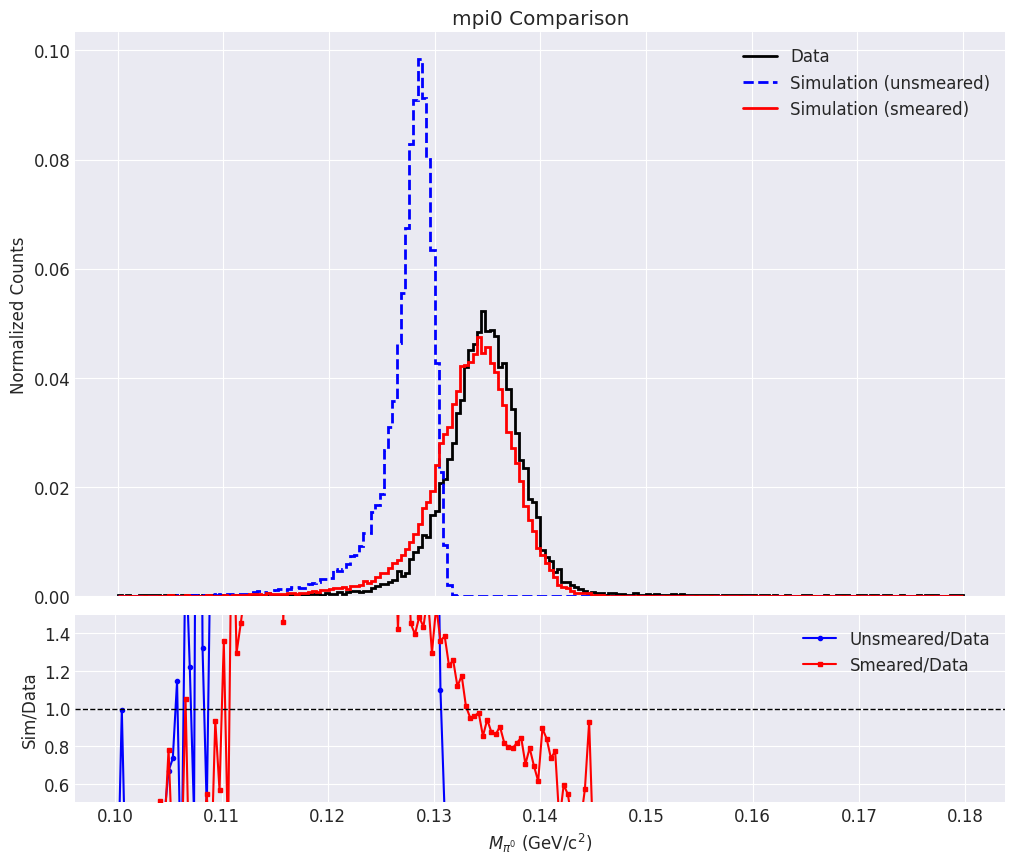

mpi0:
  Data mean/std:        0.15143 / 0.06278
  Sim mean/std:         0.12726 / 0.00307
  Smeared sim mean/std: 0.13336 / 0.00427


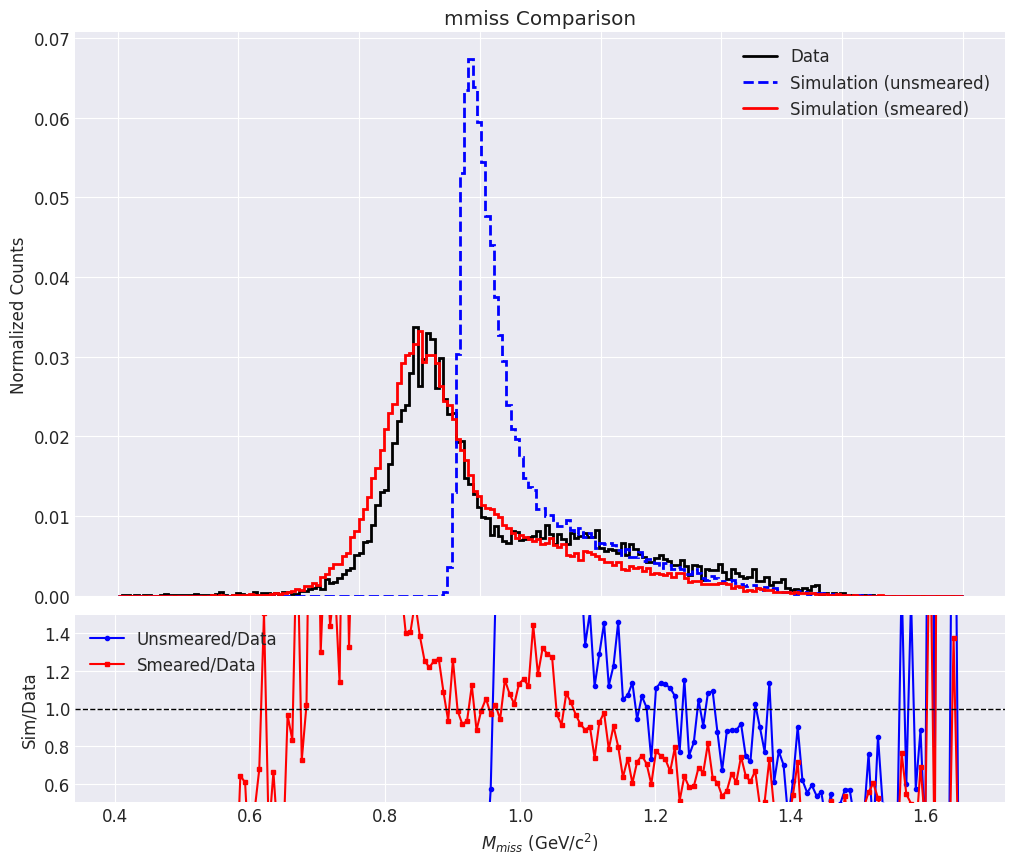

mmiss:
  Data mean/std:        0.96125 / 0.30857
  Sim mean/std:         1.06981 / 0.11706
  Smeared sim mean/std: 0.97330 / 0.15151


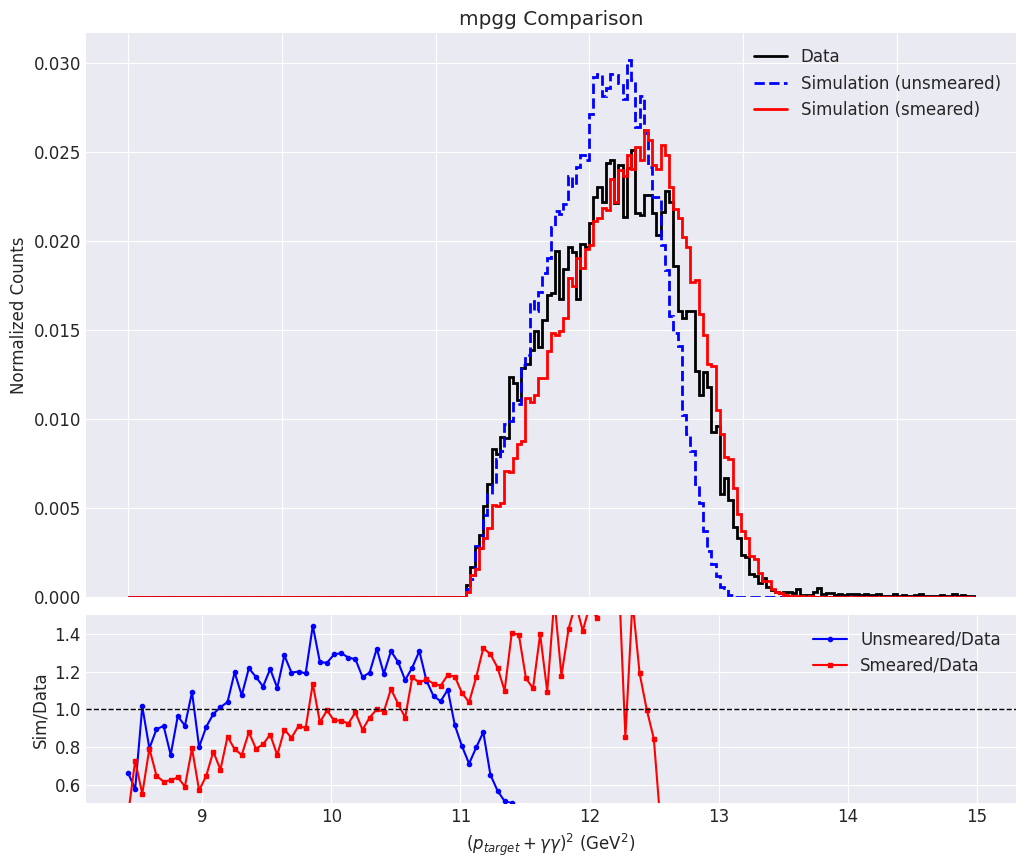

mpgg:
  Data mean/std:        10.51517 / 1.30008
  Sim mean/std:         10.14588 / 0.68362
  Smeared sim mean/std: 10.45816 / 0.80644


In [24]:
# Focused plots
plot_comparison('mpi0', bins=200, range_vals=(0.1, 0.18), xlabel=r'$M_{\pi^0}$ (GeV/c$^2$)', title='mpi0 Comparison')
plot_comparison('mmiss', bins=200, range_vals=(0.4, 1.8), xlabel=r'$M_{miss}$ (GeV/c$^2$)', title='mmiss Comparison')
plot_comparison('mpgg', bins=200, range_vals=(4.0, 15.0), xlabel=r'$(p_{target}+\gamma\gamma)^2$ (GeV$^2$)', title='mpgg Comparison')